In [ ]:
%%capture
!pip install s3fs cartopy zarr boto3 netcdf4 rasterio

In [ ]:
# If running locally, follow README.md for simple dependency installation.
# If using Google Colab, run this cell.
!uv pip install -q "xarray[complete]>=2025.3.0" "zarr>=3.0.8" requests aiohttp rioxarray pyproj
# rioxarray and pyproj are used here for working with map projections

In [ ]:
import xarray as xr

ds = xr.open_zarr("https://fdri-o.s3-ext.jc.rl.ac.uk/gearhrly/gearhrly_15day_100km_chunks.zarr", chunks=None)
ds

<xarray.Dataset> Size: 5TB
Dimensions:          (time: 236688, y: 1251, x: 701, bnds: 2)
Coordinates:
  * time             (time) datetime64[ns] 2MB 1990-01-01 ... 2016-12-31T23:0...
  * y                (y) float64 10kB 1.25e+06 1.249e+06 1.248e+06 ... 1e+03 0.0
  * x                (x) float64 6kB 0.0 1e+03 2e+03 ... 6.98e+05 6.99e+05 7e+05
    crs              int16 2B ...
    lat              (y, x) float64 7MB ...
    lon              (y, x) float64 7MB ...
    time_bnds        (time, bnds) datetime64[ns] 4MB ...
    x_bnds           (x, bnds) float64 11kB ...
    y_bnds           (y, bnds) float64 20kB ...
Dimensions without coordinates: bnds
Data variables:
    min_dist         (time, y, x) float64 2TB ...
    rainfall_amount  (time, y, x) float64 2TB ...
    stat_disag       (time, y, x) float64 2TB ...
Attributes: (12/29)
    Conventions:                   CF-1.6
    acknowledgement:               This research forms part of the SINATRA pr...
    cdm_data_type:                 Grid
    contributor_name:              Lewis, E., Quinn, N., Blenkinsop, S., Fowl...
    creator_email:                 enquiries@ceh.ac.uk
    creator_institution:           UK Centre for Ecology & Hydrology (UKCEH)
    ...                            ...
    standard_name_vocabulary:      CF Standard Name Table v70, http://cfconve...
    summary:                       The CEH-GEAR1hr-v2 dataset contains 1-km g...
    time_coverage_duration:        P27Y
    time_coverage_resolution:      P1H
    title:                         Gridded estimates of hourly areal rainfall...
    version:                       v2

In [ ]:
ds['rainfall_amount']

<xarray.DataArray 'rainfall_amount' (time: 236688, y: 1251, x: 701)> Size: 2TB
[207563778288 values with dtype=float64]
Coordinates:
  * time     (time) datetime64[ns] 2MB 1990-01-01 ... 2016-12-31T23:00:00
  * y        (y) float64 10kB 1.25e+06 1.249e+06 1.248e+06 ... 2e+03 1e+03 0.0
  * x        (x) float64 6kB 0.0 1e+03 2e+03 3e+03 ... 6.98e+05 6.99e+05 7e+05
    crs      int16 2B ...
    lat      (y, x) float64 7MB ...
    lon      (y, x) float64 7MB ...
Attributes:
    grid_mapping:   crs
    long_name:      Gridded estimates of hourly rainfall
    standard_name:  rainfall_amount
    units:          kg m-2
    valid_max:      500.0
    valid_min:      0.0

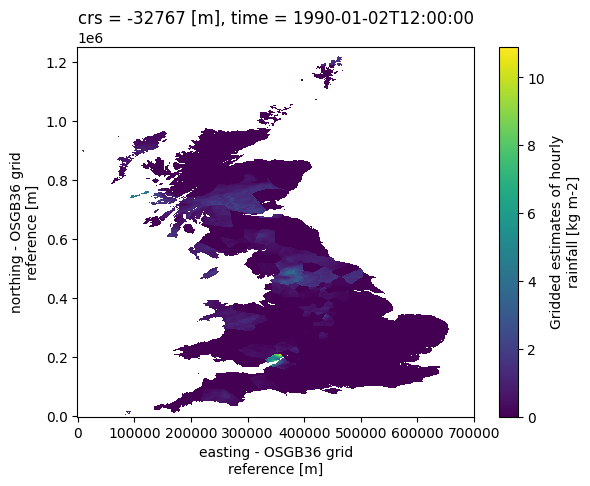

In [ ]:
ds['rainfall_amount'][36,:,:].plot()

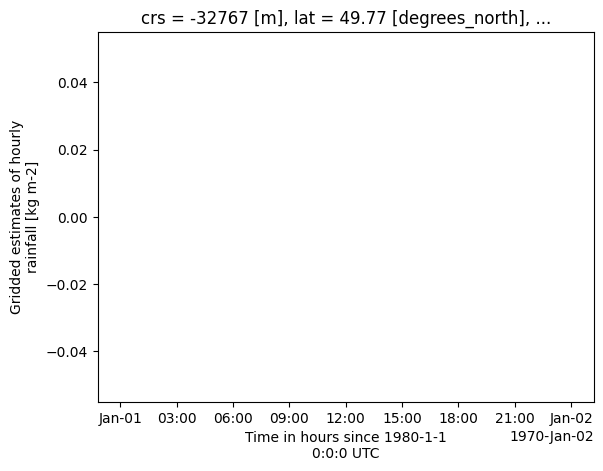

In [ ]:
(
ds['rainfall_amount']
.sel(x=0, y=0, method="nearest")
.sel(time=slice("1990-01-02T12:00:00", "1992-01-02T12:00:00"))
.plot()
)